# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_GROWTH_SURPRISE_CRASH_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-19 18:09:55.610 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/19 18:09:56 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/19 18:09:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d2c31d93-7ace-4d14-9d96-87f80b86e4dc;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 71ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/19 18:09:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 18:09:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2026-03-19 18:09:58.681 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (552702, 182)
Years: 1990


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,adjClose_GSPC,volume_GSPC,bull_market_ma,bear_market_ma,vix,vix3m,vix_vix3m_ratio,year,month,week
count,552702,552702.000000,5.527020e+05,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,...,552702.000000,5.527020e+05,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000,552702.000000
mean,2013-10-17 01:10:00.397320704,79.992698,8.443671e+06,0.000396,0.000083,-0.008010,-0.005519,-0.020348,-0.002480,0.000508,...,2495.114702,3.465248e+09,0.772724,0.227276,19.621675,16.702080,1.267604,2013.292047,6.541355,3.962045
min,1990-01-05 00:00:00,0.061792,3.500000e+01,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,300.030000,1.499000e+07,0.000000,0.000000,9.140000,5.074201,0.414363,1990.000000,1.000000,0.000000
25%,2007-05-25 00:00:00,17.620000,1.148400e+06,-0.004662,0.000004,-0.508197,-0.504950,-0.520930,-0.501235,-0.497942,...,1253.050000,2.282210e+09,1.000000,0.000000,13.940000,11.024861,1.051585,2007.000000,4.000000,4.000000
50%,2014-10-10 00:00:00,35.920000,2.491800e+06,0.000838,0.000059,-0.010142,-0.007692,-0.026549,-0.002801,0.000000,...,1955.060000,3.516400e+09,1.000000,0.000000,17.670000,13.894051,1.247184,2014.000000,7.000000,4.000000
75%,2020-10-16 00:00:00,79.820000,5.640222e+06,0.005757,0.000172,0.489796,0.492754,0.475931,0.495935,0.498936,...,3477.140000,4.397120e+09,1.000000,0.000000,22.950000,19.747207,1.444664,2020.000000,10.000000,4.000000
max,2026-03-18 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,6966.290000,1.145623e+10,1.000000,1.000000,79.130000,72.057434,2.750128,2026.000000,12.000000,4.000000
std,NaN,213.217463,4.994085e+07,0.011167,0.000082,0.577484,0.577090,0.575137,0.576775,0.576761,...,1592.386774,1.728018e+09,0.419073,0.419073,8.109537,9.350660,0.320690,8.120286,3.462680,0.215576


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [ ]:
import pandas as pd
import numpy as np

def target_period_fixed(df, period='3ME'):
    """
    Calcule la target sur des périodes fixes (ex: trimestres civils).
    La target représente le rendement de la PROCHAINE période complète.
    """
    df = df.sort_values(by=['symbol', 'date'])
    
    # 1. Extraire le dernier prix disponible pour chaque période fixe
    target = df.groupby(['symbol', pd.Grouper(key='date', freq=period)])['adjClose'].last().reset_index()
    
    # 🚀 LA CORRECTION CRUCIALE : Calcul du rendement FUTUR (T vers T+1)
    # On prend le prix de la période SUIVANTE (shift(-1)) qu'on divise par le prix actuel
    target['target_y'] = target.groupby('symbol')['adjClose'].shift(-1) / target['adjClose'] - 1
    
    # On supprime la toute dernière période car on ne connaît pas encore son futur
    target = target.dropna(subset=['target_y'])
    target = target[['symbol', 'date', 'target_y']]

    # 2. Joindre la target fixe aux données journalières
    # On trie impérativement par date pour que merge_asof fonctionne
    df = df.sort_values(by='date')
    target = target.sort_values(by='date')
    
    df = pd.merge_asof(
        df,
        target,
        on='date',
        by='symbol',
        direction='forward'
    )
    df['target_y'] = df['target_y'].fillna(0)
    # On retrie proprement par action et par date à la fin
    return df.sort_values(by=['symbol', 'date']).reset_index(drop=True)

# Application sur ton dataset
df = target_period_fixed(df, period='1YE')


## 4. Algorithm Model Architectures

In [5]:
Valorisation = ['priceToBookRatio', 'priceToSalesRatio', 'priceToEarningsRatio', 'evToEBITDA', 'freeCashFlowYield']
Profitable = ['returnOnEquity', 'returnOnInvestedCapital', 'returnOnAssets', 'grossProfitMargin', 'operatingProfitMargin', 'ebitdaMargin']
Momentum = ['market_return', 'risk_free_rate', 'retvol', 'maxret', 'ill', 'beta', 'mom1w', 'mom1m', 'mom3m', 'mom6m', 'mom12m', 'mom36m', 'mom60m', 'chmom', 'high52', 'dist_ma4', 'dist_ma12', 'dist_ma25', 'dist_ma50']
colonnes_biais = ['date', 'volume', 'adjClose','symbol',  'target_y', 'year', 'adjClose_GSPC', 'volume_GSPC']
reduce_features = [
    'dividendYieldPercentage',
    'bear_market_ma',
    'enterpriseValueMultiple',
    'freeCashFlowOperatingCashFlowRatio',
    'operatingProfitMargin',
    'pretaxProfitMargin',
    'bottomLineProfitMargin',
    'continuousOperationsProfitMargin',
    'ebitMargin',
    'priceToFreeCashFlowRatio',
    'priceToOperatingCashFlowRatio',
    'netDebtToEBITDA',
    'solvencyRatio',
    'quickRatio', 
    'daysOfInventoryOutstanding',
    'operatingCycle',
    'workingCapital',
    'returnOnTangibleAssets',
    'inventoryTurnover',
    'returnOnAssets', 
    'debtToAssetsRatio', 
    'assetTurnover', 
    'evToFreeCashFlow', 
    'evToOperatingCashFlow', 
    'evToSales', 
    'ebitdaMargin', 
    'operatingCashFlowSalesRatio', 
    'salesGeneralAndAdministrativeToRevenue', 
    'dist_ma25', 
    'dist_ma50', 
    'dividendYield', 
    'debtServiceCoverageRatio', 
    'financialLeverageRatio', 
    'vix', 
    'bookValuePerShare', 
    'investedCapital', 
    'netIncomePerEBT', 
    'netProfitMargin', 
    'taxBurden',
    'inventoryGrowth',
    'assetGrowth',
    'bookValueperShareGrowth',
    'dividendsPerShareGrowth',
    'operatingCashFlowGrowth',
    'epsgrowth',
    'weightedAverageSharesGrowth',
    'grossProfitGrowth',
    'tenYShareholdersEquityGrowthPerShare',
    'priceToBookRatio',
    'returnOnEquity',
    'priceToFairValue',
    'tenYBottomLineNetIncomeGrowthPerShare',
    'epsActual',
    'epsEstimated', 
    'revenueActual',
    'revenueEstimated']
#reduce_features = []

colunms = df.columns.tolist()
string_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Colonnes de type texte :", string_cols)

# 2. Ta logique d'ensembles (sets) était parfaite, on la garde !
# J'ai juste simplifié la soustraction pour que ce soit plus lisible
#features = list((set(colunms)) - (set(colonnes_biais) | set(string_cols)))
features = list((set(colunms)) - (set(colonnes_biais) | set(reduce_features) | set(string_cols)))

print("Nombre de features conservées :", len(features))
# print("features :", features)


Colonnes de type texte : ['symbol', 'fiscalYear', 'period', 'reportedCurrency', 'lastUpdated']
Nombre de features conservées : 115


In [6]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol                 0
date                   0
adjClose               0
volume                 0
market_return          0
                   ...  
vix_vix3m_ratio        0
year                   0
month                  0
week                   0
target_y           11409
Length: 183, dtype: int64
Data after target creation: (552702, 183)
Years: 1990


## 2. Expanding Window Time-Series Split

In [7]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")


Total years in dataset: 1990 to 2026
Train ends before: 2012
Validation: 2012 to 2016
Test: 2017 to 2026

Total static splits: 1
Split 1 | Test Period: 2017 | Train: 221390 rows | Val: 103513 rows | Test: 227799 rows


In [8]:
"""
def get_train_val_test_splits(df, initial_train_years=30, val_years=3, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=30, val_years=3, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr) 

## Reduction Features

Features supprimées (corrélation > 0.8) : 3
{'mom1m', 'freeCashFlowToEquity', 'forwardPriceToEarningsGrowthRatio'}
Dimensions avant PCA : (221390, 112)


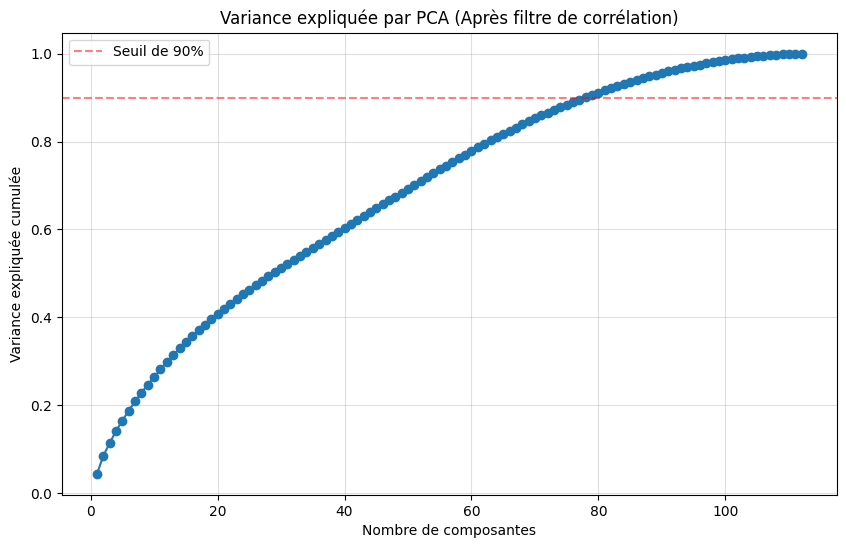

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features supprimées (corrélation > {threshold}) : {len(col_corr)}")
    print(col_corr)

    # CORRECTION : On applique VRAIMENT la réduction !
    df_reduced = X_train_df.drop(columns=col_corr)
    print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA
    # ---------------------------------------------------------
    scaler = StandardScaler()
    # CORRECTION : On fit le scaler sur df_reduced, pas sur X_train_df
    X_train_scale = scaler.fit_transform(df_reduced) 
    
    pca = PCA()
    pca.fit(X_train_scale)

    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%')
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

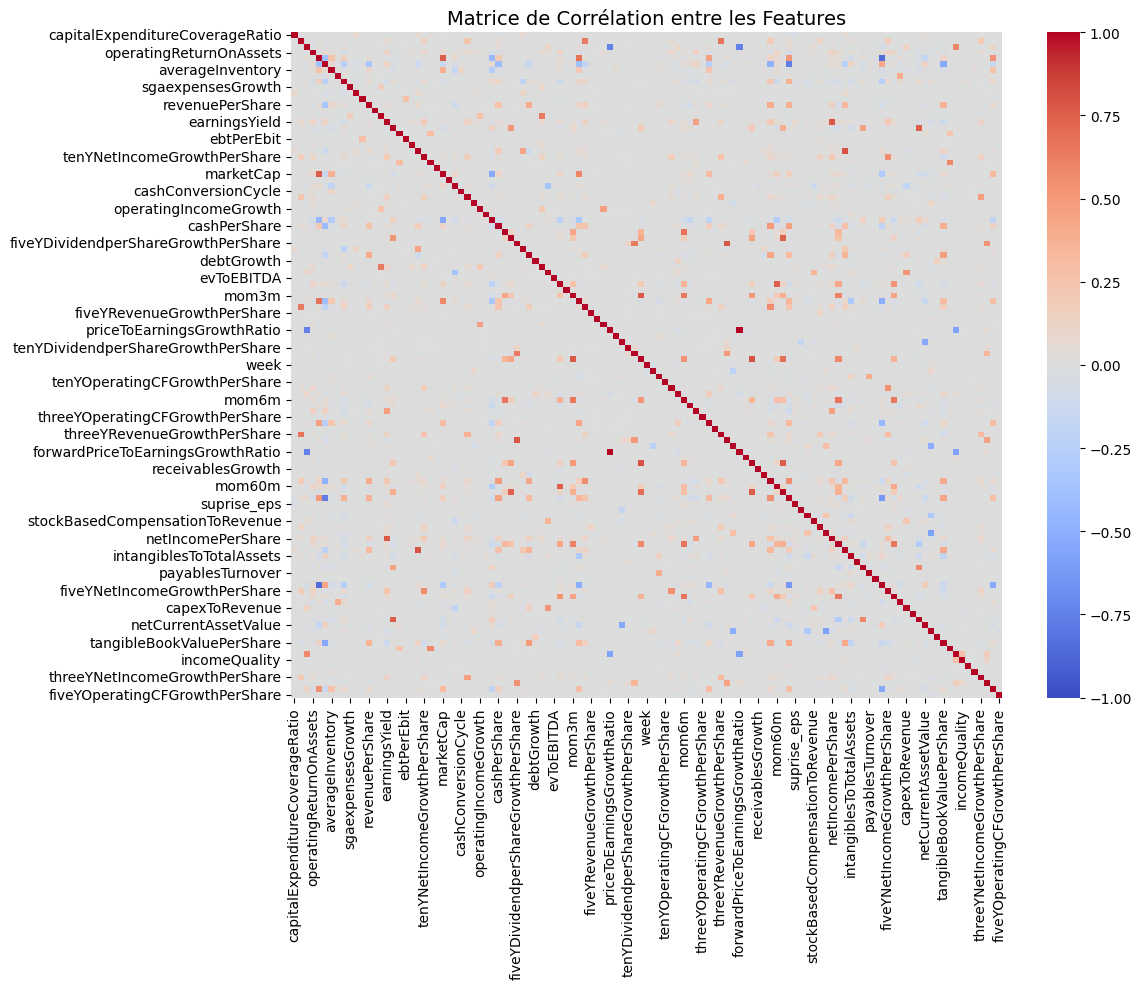


🔥 TOP 20 des paires de variables les plus corrélées :
freeCashFlowToEquity                    enterpriseValue                       -0.844088
dist_ma12                               mom1m                                  0.802068
freeCashFlowPerShare                    operatingCashFlowPerShare              0.793450
dividendPerShare                        fiveYDividendperShareGrowthPerShare    0.787986
earningsYield                           netIncomePerShare                      0.781033
interestDebtPerShare                    grahamNetNet                          -0.772557
dist_ma12                               mom3m                                  0.771569
marketCap                               enterpriseValue                        0.762090
dist_ma4                                mom1m                                  0.762040
mom36m                                  mom60m                                 0.752563
maxret                                  retvol                   

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# VISUALISATION DE LA MATRICE DE CORRÉLATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 10)) # Taille ajustable selon le nombre de tes features

# Création de la heatmap
# vmin et vmax forcent l'échelle de -1 (rouge inverse) à 1 (bleu)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title("Matrice de Corrélation entre les Features", fontsize=14)
plt.tight_layout()
plt.show()

# Astuce bonus : Afficher le TOP 10 des paires les plus corrélées (en texte)
print("\n🔥 TOP 20 des paires de variables les plus corrélées :")
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
# On enlève la corrélation de 1.0 (une variable avec elle-même) et on enlève les doublons
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()
print(corr_pairs.head(20))

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [11]:
def calculate_r2_oos(y_true, y_pred):
    """
    Out-of-Sample R^2.
    Denominator uses 0 as the prediction benchmark (predicting exactly zero excess return).
    """
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - 0)**2)
    return 1 - (numerator / denominator)

In [12]:
import scipy.stats as stats
import numpy as np

def calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=0.0):
    """
    Calcule le Probabilistic Sharpe Ratio (PSR) de Lopez de Prado.
    Renvoie la probabilité que le Sharpe Ratio soit statistiquement supérieur au benchmark.
    
    returns : Series Pandas des rendements périodiques du portefeuille (ex: hebdomadaires)
    benchmark_sr : Le Sharpe Ratio à battre (0.0 par défaut, ou le SR du S&P 500)
    """
    # On enlève les NaN éventuels
    returns = returns.dropna()
    n = len(returns)
    
    if n < 3:
        return 0.0
        
    # Calcul des statistiques de base sur les rendements bruts (non annualisés)
    sr_raw = np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0.0
    
    # Skewness (Asymétrie) et Kurtosis (Aplatissement)
    skewness = stats.skew(returns)
    kurtosis = stats.kurtosis(returns, fisher=False) # Fisher=False pour avoir un kurtosis normal autour de 3
    
    # Formule mathématique du PSR
    # Dénominateur : ajustement pour la non-normalité des rendements financiers
    denominator = np.sqrt(1 - skewness * sr_raw + ((kurtosis - 1) / 4) * (sr_raw ** 2))
    
    if denominator == 0:
        return 0.0
        
    # Calcul de la Z-score
    z_score = ((sr_raw - benchmark_sr) * np.sqrt(n - 1)) / denominator
    
    # On passe la Z-score dans la fonction de répartition (CDF) de la loi normale
    psr = stats.norm.cdf(z_score)
    
    return psr

### OLS

In [13]:
def train_ols(X_train_scaled, y_train):
    with mlflow.start_run(run_name="OLS", nested=True):
        ols = LinearRegression()
        ols.fit(X_train_scaled, y_train)
        return ols

### Lasso

In [14]:
def train_lasso(X_train_scaled, y_train):
    with mlflow.start_run(run_name="Lasso", nested=True):
        lasso = Lasso(alpha=0.01, random_state=42)
        lasso.fit(X_train_scaled, y_train)
        return lasso

### Ridge

In [15]:
def train_ridge(X_train_scaled, y_train):
    with mlflow.start_run(run_name="Ridge", nested=True):
        ridge = Ridge(alpha=1.0, random_state=42)
        ridge.fit(X_train_scaled, y_train)
        return ridge

### Random Forest

In [16]:
def train_rf(X_train_scaled, y_train):
    with mlflow.start_run(run_name="RandomForest", nested=True):
        rf = RandomForestRegressor(n_estimators=500, max_depth=10, n_jobs=-1, random_state=42)
        rf.fit(X_train_scaled, y_train)
        return rf

### XGBoost

In [17]:
def train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val):
    with mlflow.start_run(run_name="XGBoost", nested=True):
        xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
        return xgb_model

### LightGBM

In [18]:
def train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val):
    with mlflow.start_run(run_name="LightGBM", nested=True):
        lgbm = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
        lgbm.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])
        return lgbm

### Catboost

In [19]:
def train_catboost(X_train_scaled, y_train, X_val_scaled, y_val):
    with mlflow.start_run(run_name="CatBoost", nested=True):
        cb = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, random_seed=42, verbose=False, thread_count=-1)
        cb.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), use_best_model=True)
        return cb

### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [20]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective='val_loss',
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        
        # Pass the datasets instead of raw arrays. Drop the 'batch_size' arg since the dataset handles it.
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
    
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Top)

In [21]:
import pandas as pd
import numpy as np

def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    Invests strictly in the Top N performing stocks based on predictions_col.
    Returns the backtest time series, the summary metrics, and the detailed trade history.
    """
    results = []
    trades_history = [] # 🛠️ NOUVEAU : Initialisation de l'historique des positions
    
    # CRITICAL FIX 1: Sort dataframe before shift(-1)
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calculate future return (what we will earn if we hold for the next period)
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # Initialize empty set to track what we held the previous week
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        # Skip weeks with too few stocks to form a proper Top N portfolio
        if len(week_data) < top_n: 
            continue
            
        week_data = week_data.copy()
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO TOP N (LONG ONLY) ---
        try:
            # On trie les actions par la colonne de prédiction/performance
            # ascending=False permet d'avoir les plus grandes valeurs en haut
            week_data = week_data.sort_values(by=predictions_col, ascending=False)
            
            # On prend strictement le Top N
            long_portfolio = week_data.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # 🛠️ NOUVEAU : Sauvegarde du détail de chaque action détenue cette semaine
                for _, row in long_portfolio.iterrows():
                    trades_history.append({
                        'date': date,
                        'symbol': row['symbol'],
                        'prediction_score': row[predictions_col], # Optionnel mais très utile pour déboguer !
                        'return': row['return+1']
                    })

                # Gross Return (Equal-Weighted)
                ret_long = long_portfolio['return+1'].mean()
                gross_portfolio_return = ret_long 
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Turnover: Fraction of the portfolio that is new
                turnover_long = len(new_longs) / num_l if prev_long_symbols else 1.0 
                
                # Fee to BUY the new stock AND SELL the old stock
                cost_long = turnover_long * transaction_cost * 2
                
                # Net Return
                net_portfolio_return = gross_portfolio_return - cost_long
                
                # Update memory for the next loop
                prev_long_symbols = curr_long_symbols
            else:
                ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
                
        except Exception as e:
            ret_long, gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0, 0
            
        # Append results for this week
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)
    trades_df = pd.DataFrame(trades_history) # 🛠️ NOUVEAU : Conversion en DataFrame

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}, trades_df # 🛠️ NOUVEAU : On retourne aussi le df vide en cas d'erreur
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    # Cumulative returns
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    # Portfolio Metrics
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()
    
    # NOTE: J'ai laissé tes fonctions PSR/PBO telles quelles, assure-toi qu'elles soient bien importées.
    try:
        psr = calculate_probabilistic_sharpe_ratio(bt_df['portfolio_return'])
        pbo = 1.0 - psr
    except NameError:
        psr, pbo = 0, 0 # Fallback de sécurité si la fonction n'est pas définie dans ton script global

    # Benchmark Metrics
    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Prob_Overfitting': pbo,
        'PSR': psr,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    # 🛠️ NOUVEAU : On retourne maintenant 3 éléments
    return bt_df, metrics, trades_df

## 6. Run the Pipeline over the Expanding Window

In [22]:
if len(splits) > 0:

    print("🧹 Nettoyage des données avant l'entraînement...")

    # 1. On remplace les potentiels infinis (parfois générés par des divisions par zéro dans les ratios financiers) par des NaN
    df = df.replace([np.inf, -np.inf], np.nan)

    # 2. On supprime TOUTES les lignes où la variable cible (target_y) est manquante
    df = df.dropna(subset=['target_y'])

    # 3. (Optionnel mais recommandé) On supprime aussi les lignes où tes features sont manquantes
    df = df.dropna(subset=features)

    df = df.reset_index(drop=True)

    print(f"✅ Nettoyage terminé. Taille du dataset : {df.shape}")

    splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)
    
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 an fixe"
    NUM_SPLITS = 1
    TOP = 50
    NOTES = "Test avec une target de 1 an fixe. Comparaison de 8 Modèles. Avec Réduction de features. Full Data"

    mlflow.set_experiment("Maximize_CAGR_SP500_Regression")
    
    run_name = f"Test_{STRATEGY_FREQ}_MultiModels_Target{TARGET_FREQ}_Top{TOP}"

    # Liste de nos modèles pour automatiser les boucles
    model_keys = ['dnn', 'rf', 'ols', 'lasso', 'ridge', 'xgboost', 'lightgbm', 'catboost']

    with mlflow.start_run(run_name="CAGR_Forward_Backtest_Multi") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "transaction_cost": TRANS_COST,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # =========================================================
        # 1. LA BOUCLE SUR TOUTES LES ANNÉES
        # =========================================================
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.fit_transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val)
            
            # --- ENTRAÎNEMENTS ---
            print("  -> Training DNN...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            
            print("  -> Training ML Models...")
            rf_model = train_rf(X_train, y_train)
            ols_model = train_ols(X_train_scaled, y_train)
            lasso_model = train_lasso(X_train_scaled, y_train)
            ridge_model = train_ridge(X_train_scaled, y_train)
            xgboost_model = train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val)
            lightgbm_model = train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val)
            catboost_model = train_catboost(X_train_scaled, y_train, X_val_scaled, y_val)
            
            # --- PRÉDICTIONS GROUPÉES ---
            # On stocke tout dans un dictionnaire pour faciliter le traitement
            preds_dict = {
                'dnn': predict_dnn_ensemble(dnn_models, scaler, X_test_scaled),
                'rf': rf_model.predict(X_test_scaled),
                'ols': ols_model.predict(X_test_scaled),
                'lasso': lasso_model.predict(X_test_scaled),
                'ridge': ridge_model.predict(X_test_scaled),
                'xgboost': xgboost_model.predict(X_test_scaled),
                'lightgbm': lightgbm_model.predict(X_test_scaled),
                'catboost': catboost_model.predict(X_test_scaled)
            }
            
            # Préparation du DataFrame pour cette année
            test_df_year = df.loc[test_idx].copy()
            
            # --- SUIVI ANNÉE PAR ANNÉE POUR TOUS LES MODÈLES ---
            for model_name, preds in preds_dict.items():
                r2_year = float(calculate_r2_oos(y_test.values, preds))
                mlflow.log_metric(f"Yearly_{model_name.upper()}_R2_OOS", r2_year, step=int(test_year))
                
                # Ajout de la colonne de prédiction dans le DataFrame
                test_df_year[f'{model_name}_pred'] = preds
                
            print(f"  -> R2 {test_year} | DNN: {float(calculate_r2_oos(y_test.values, preds_dict['dnn'])):.4f} | XGB: {float(calculate_r2_oos(y_test.values, preds_dict['xgboost'])):.4f} | RF: {float(calculate_r2_oos(y_test.values, preds_dict['rf'])):.4f}")
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 2. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul des Backtests...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        # Dictionnaire pour stocker les résultats finaux de chaque modèle
        final_metrics = {}
        
        for model_name in model_keys:
            pred_col = f'{model_name}_pred'
            
            # 1. Calcul du R2 Global
            r2_global = float(calculate_r2_oos(final_test_df['target_y'].values, final_test_df[pred_col].values))
            mlflow.log_metric(f"Global_{model_name.upper()}_R2_OOS", r2_global)
            
            # 2. Backtest du Portefeuille
            print(f"Running Backtest for {model_name.upper()}...")
            bt_df, metrics, trades_df = backtest_portfolio(final_test_df, pred_col, transaction_cost=TRANS_COST, top_n=TOP)
            
            if not bt_df.empty:
                # Log MLflow
                mlflow.log_metrics({f"{model_name.upper()}_{k}": float(v) for k, v in metrics.items()})
                # Ajout au dictionnaire global pour le tableau
                final_metrics[model_name.upper()] = metrics
            else:
                print(f"  ⚠️ Backtest vide pour {model_name.upper()}.")

        # =========================================================
        # 3. AFFICHAGE DU TABLEAU COMPARATIF FINAL
        # =========================================================
        if final_metrics:
            # 1. On initialise le tableau avec le nom des métriques
            metrics_table_data = {
                "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown", "Probabilité Overfitting"]
            }
            
            # 2. On ajoute le Benchmark en premier (on peut prendre les stats du Benchmark 
            # depuis n'importe quel modèle, par exemple le premier de la liste, car c'est le même pour tous)
            first_model = list(final_metrics.keys())[0]
            metrics_table_data["S&P 500 (Benchmark)"] = [
                f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
                f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%",
                "N/A"
            ]

            # 3. On boucle sur TOUS les modèles pour remplir les colonnes suivantes
            for model_name, metrics in final_metrics.items():
                metrics_table_data[model_name] = [
                    f"{metrics['Total_Return']*100:.2f}%", 
                    f"{metrics['CAGR']*100:.2f}%", 
                    f"{metrics['Sharpe_Ratio']:.2f}", 
                    f"{metrics['Max_Drawdown']*100:.2f}%",
                    f"{metrics['Prob_Overfitting']*100:.2f}%"
                ]
                
            # 4. On crée le DataFrame à partir du dictionnaire final
            metrics_table = pd.DataFrame(metrics_table_data)
            
            # Affichage de la grille complète
            print("\n" + "="*120)
            print("📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)")
            print("="*120)
            print(metrics_table.to_string(index=False))
            print("="*120 + "\n")
            
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
else:
    print("Not enough data to form a split. Check your timeframe.")


🧹 Nettoyage des données avant l'entraînement...
✅ Nettoyage terminé. Taille du dataset : (541293, 183)
Total years in dataset: 1990 to 2025
Train ends before: 2011
Validation: 2011 to 2015
Test: 2016 to 2025
🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2016 (1/1) ---
  -> Training DNN...


2026-03-19 18:10:45.527523: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-19 18:10:45.527552: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-19 18:10:45.527564: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1773940245.527577  420023 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773940245.527596  420023 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starting KerasTuner RandomSearch...
Best HPs found: Layer1: 32, Layer2: 24, LR: 0.01


2026-03-19 18:11:01.292032: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-19 18:11:01.316095: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-19 18:11:01.657265: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

2026/03/19 18:11:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/19 18:11:49 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.11295206844806671 is not in list


Trained DNN component 5/5 - Best Val Loss: 0.115297
  -> Training ML Models...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28577
[LightGBM] [Info] Number of data points in the train set: 201153, number of used features: 115
[LightGBM] [Info] Start training from score 0.126936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  -> R2 2016 | DNN: -957590397.8641 | XGB: -1.7666 | RF: -22.0786

🔗 Assemblage des prédictions et calcul des Backtests...
Running Backtest for DNN...
Running Backtest for RF...
Running Backtest for OLS...
Running Backtest for LASSO...
Running Backtest for RIDGE...
Running Backtest for XGBOOST...
Running Backtest for LIGHTGBM...
Running Backtest for CATBOOST...

📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)
               Métrique S&P 500 (Benchmark)     DNN      RF     OLS   LASSO   RIDGE XGBOOST LIGHTGBM CATBOOST
           Total Return             406.21% 413.06% 205.95% 399.45% 461.17% 395.73% 526.22%  509.42%  577.06%
       CAGR (Annualisé)              17.61%  17.77%  11.83%  17.45%  18.83%  17.36%  20.14%   19.81%   21.08%
           Sharpe Ratio                0.91    0.86    0.56    0.78    0.76    0.78    0.87     0.87     0.96
           Max Drawdown             -33.04% -33.89% -46.53% -40.02% -46.68% -40.25% -43.15%  -42.69%  -35.14%
Probabilité Overfitti

## 7. Visualisation results

🚀 Lancement des backtests pour tous les modèles...
  -> Backtest en cours pour DNN...
  -> Backtest en cours pour Random Forest...
  -> Backtest en cours pour OLS...
  -> Backtest en cours pour Lasso...
  -> Backtest en cours pour Ridge...
  -> Backtest en cours pour XGBoost...
  -> Backtest en cours pour LightGBM...
  -> Backtest en cours pour CatBoost...

📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)
        Métrique S&P 500 (Benchmark)     DNN Random Forest     OLS   Lasso   Ridge XGBoost LightGBM CatBoost
    Total Return             406.21% 649.90%       113.14% 330.48% 576.32% 331.68% 596.95%  728.96% 1834.81%
CAGR (Annualisé)              17.61%  22.32%         7.86%  15.72%  21.06%  15.75%  21.43%   23.55%   34.48%
    Sharpe Ratio                0.91    0.81          0.39    0.67    0.77    0.67    0.77     0.86     0.97
    Max Drawdown             -33.04% -43.16%       -62.20% -45.64% -48.06% -45.64% -47.71%  -55.13%  -44.27%



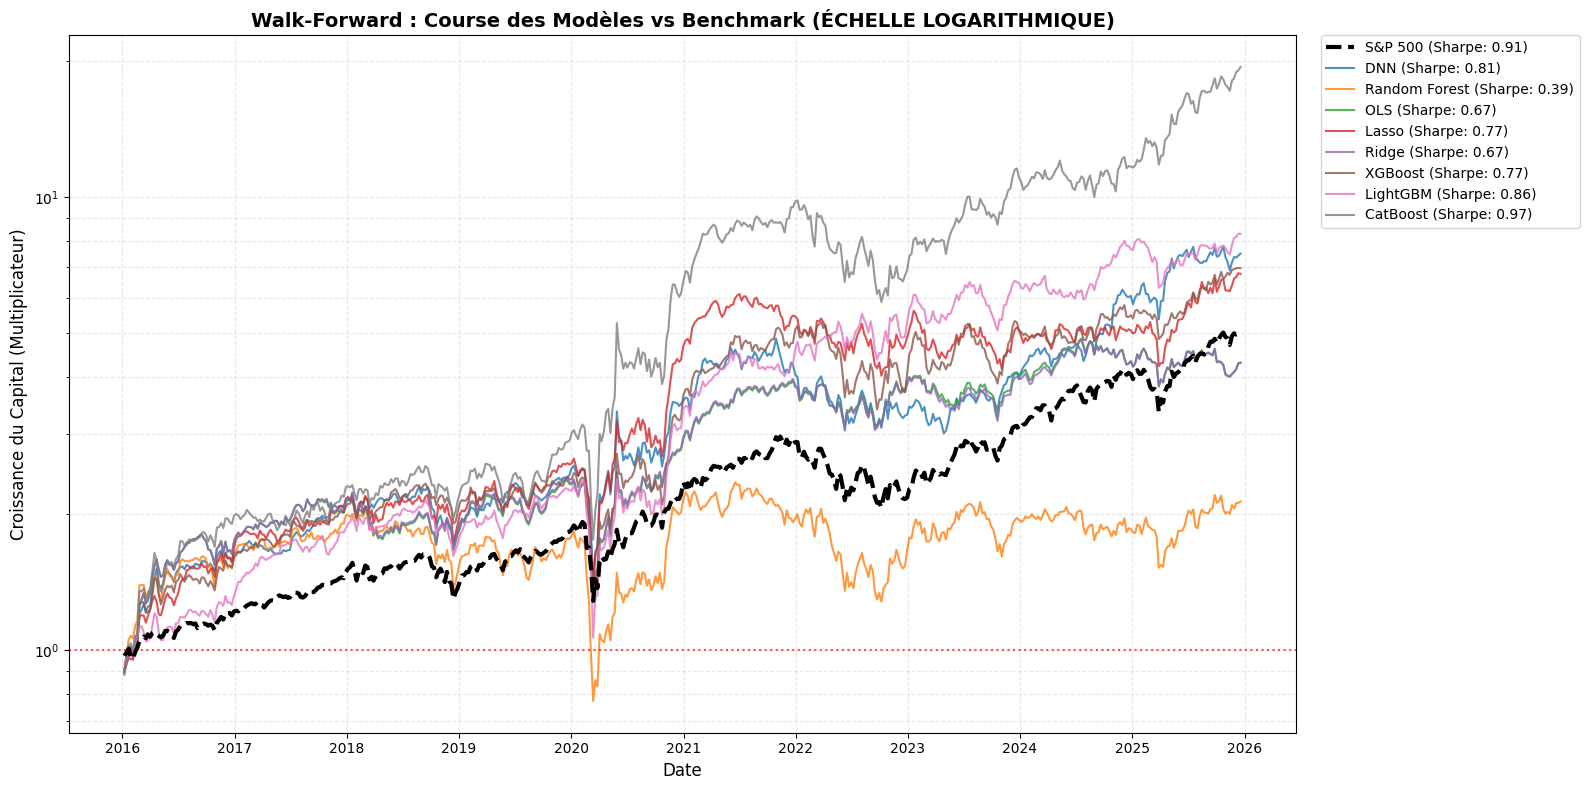

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 Lancement des backtests pour tous les modèles...")

# 1. On liste tous les modèles et leurs colonnes de prédictions correspondantes
models_to_test = {
    'DNN': 'dnn_pred',
    'Random Forest': 'rf_pred',
    'OLS': 'ols_pred',
    'Lasso': 'lasso_pred',
    'Ridge': 'ridge_pred',
    'XGBoost': 'xgboost_pred',
    'LightGBM': 'lightgbm_pred',
    'CatBoost': 'catboost_pred'
}

# On initialise nos fameux dictionnaires !
all_bt_df = {}
final_metrics = {}

# 2. On boucle pour calculer le backtest de chaque modèle
for model_name, pred_col in models_to_test.items():
    # On vérifie par sécurité que la colonne existe bien dans final_test_df
    if pred_col in final_test_df.columns:
        print(f"  -> Backtest en cours pour {model_name}...")
        bt_df, metrics, trades_df = backtest_portfolio(final_test_df, pred_col, transaction_cost=0.001, top_n=10)
        
        # Si le backtest a fonctionné, on le stocke
        if not bt_df.empty:
            all_bt_df[model_name] = bt_df
            final_metrics[model_name] = metrics
        else:
            print(f"  ⚠️ Le backtest pour {model_name} est vide.")
    else:
        print(f"  ❌ Colonne {pred_col} introuvable. Modèle ignoré.")

# Si on a au moins un modèle réussi, on passe à l'affichage
if final_metrics:
    
    # ==========================================
    # 3. TABLEAU DES PERFORMANCES MULTI-MODÈLES
    # ==========================================
    metrics_table_data = {
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"]
    }
    
    # Ajout du Benchmark (S&P 500) en premier
    first_model = list(final_metrics.keys())[0]
    metrics_table_data["S&P 500 (Benchmark)"] = [
        f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
        f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%"
    ]

    # Ajout de tous les modèles
    for model_name, metrics in final_metrics.items():
        metrics_table_data[model_name] = [
            f"{metrics['Total_Return']*100:.2f}%", 
            f"{metrics['CAGR']*100:.2f}%", 
            f"{metrics['Sharpe_Ratio']:.2f}", 
            f"{metrics['Max_Drawdown']*100:.2f}%"
        ]
        
    metrics_table = pd.DataFrame(metrics_table_data)
    
    print("\n" + "="*120)
    print("📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)")
    print("="*120)
    print(metrics_table.to_string(index=False))
    print("="*120 + "\n")

    # ==========================================
    # 4. GRAPHIQUE MULTI-COURBES (ÉCHELLE LOG)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # On trace la courbe du S&P 500 (Benchmark) en noir épais
    first_bt = list(all_bt_df.values())[0]
    bench_sharpe = final_metrics[first_model]['Bench_Sharpe']
    ax1.plot(first_bt['date'], first_bt['cum_benchmark'], label=f"S&P 500 (Sharpe: {bench_sharpe:.2f})", color='black', linestyle='--', linewidth=3, zorder=10)

    # On trace les courbes de tous les modèles IA
    for model_name, bt_data in all_bt_df.items():
        sharpe = final_metrics[model_name]['Sharpe_Ratio']
        # Les modèles avec un bon Sharpe auront tendance à se démarquer visuellement
        ax1.plot(bt_data['date'], bt_data['cum_return'], label=f"{model_name} (Sharpe: {sharpe:.2f})", linewidth=1.5, alpha=0.8)

    # Ligne de base (Capital de départ)
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.7)
    
    # Paramètres d'affichage
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward : Course des Modèles vs Benchmark (ÉCHELLE LOGARITHMIQUE)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Croissance du Capital (Multiplicateur)', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    
    # On met la légende à l'extérieur pour ne pas cacher les courbes
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., fontsize=10) 
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Tous les backtests ont échoué ou sont vides.")

In [24]:
top_n = 10
transactio_cost = 0.001
pred_col = "xgboost_pred"
bt_df, metrics, dict_des_trades = backtest_portfolio(final_test_df, pred_col, transaction_cost=transactio_cost, top_n=top_n)
dict_des_trades.tail(50)

,date,symbol,prediction_score,return
5160,2025-11-28,CHTR,4.193518,0.024885
5161,2025-11-28,AES,2.780192,-0.010079
5162,2025-11-28,F,2.494947,-0.019026
5163,2025-11-28,AAL,2.455033,0.054093
5164,2025-11-28,PCG,2.444537,-0.059739
5165,2025-11-28,EIX,2.321644,-0.013441
5166,2025-11-28,AMCR,1.633105,-0.025922
5167,2025-11-28,MTCH,1.600746,0.036232
5168,2025-11-28,WB,1.320269,0.048290
5169,2025-11-28,BDX,1.232394,-0.000398


🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_28993/1919148620.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)


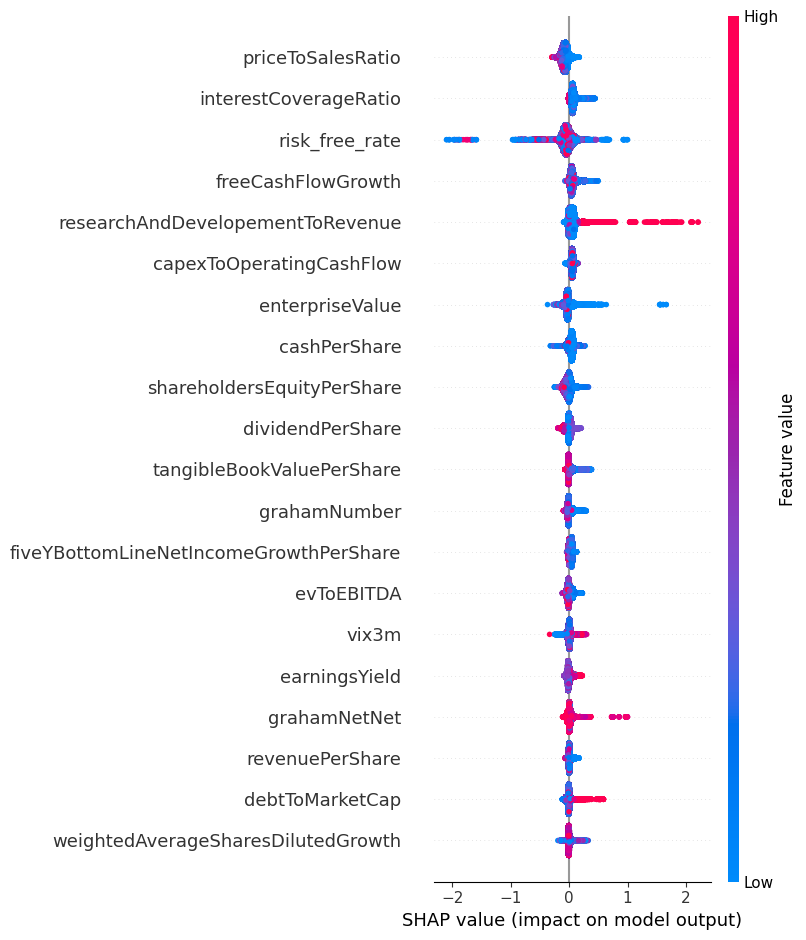

In [25]:
import shap
import matplotlib.pyplot as plt

print("🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...")

# 1. Création de l'explainer (Le "scanner" de cerveau pour LightGBM)
explainer = shap.TreeExplainer(lightgbm_model)

# 2. On calcule les valeurs SHAP sur ton dernier jeu de test
# ⚠️ Attention : on utilise X_test_scaled car le modèle a appris sur des données scalées !
shap_values = explainer.shap_values(X_test_scaled)

# 3. Gestion de la structure de sortie (Classification Binaire)
# Selon la version de LightGBM/SHAP, la sortie peut être une liste contenant [valeurs_pour_0, valeurs_pour_1]
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1] # On regarde l'impact pour la classe 1 (Les "gagnants")
else:
    shap_vals_to_plot = shap_values

# 4. Affichage du graphique magique
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)

🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_28993/4159876748.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)


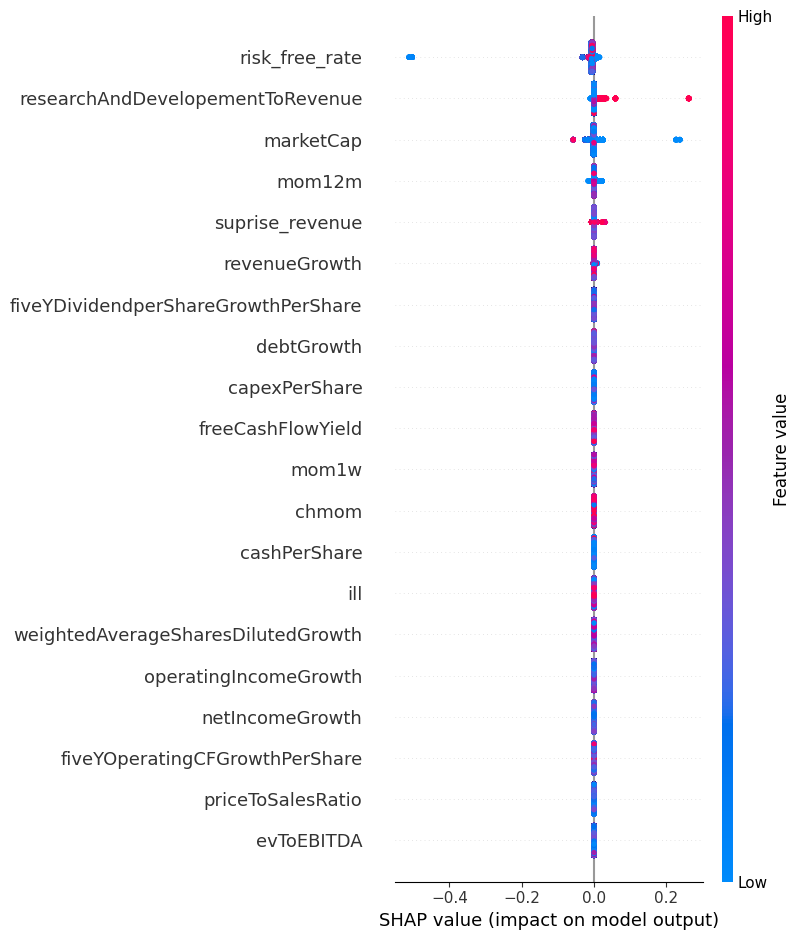

In [26]:
import shap
import matplotlib.pyplot as plt

print("🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...")

# 1. Création de l'explainer (Le "scanner" de cerveau pour LightGBM)
explainer = shap.TreeExplainer(catboost_model)

# 2. On calcule les valeurs SHAP sur ton dernier jeu de test
# ⚠️ Attention : on utilise X_test_scaled car le modèle a appris sur des données scalées !
shap_values = explainer.shap_values(X_test_scaled)

# 3. Gestion de la structure de sortie (Classification Binaire)
# Selon la version de LightGBM/SHAP, la sortie peut être une liste contenant [valeurs_pour_0, valeurs_pour_1]
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1] # On regarde l'impact pour la classe 1 (Les "gagnants")
else:
    shap_vals_to_plot = shap_values

# 4. Affichage du graphique magique
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)

⚡ Calcul des SHAP sur un échantillon (Version Rapide)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_28993/3170964639.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features)


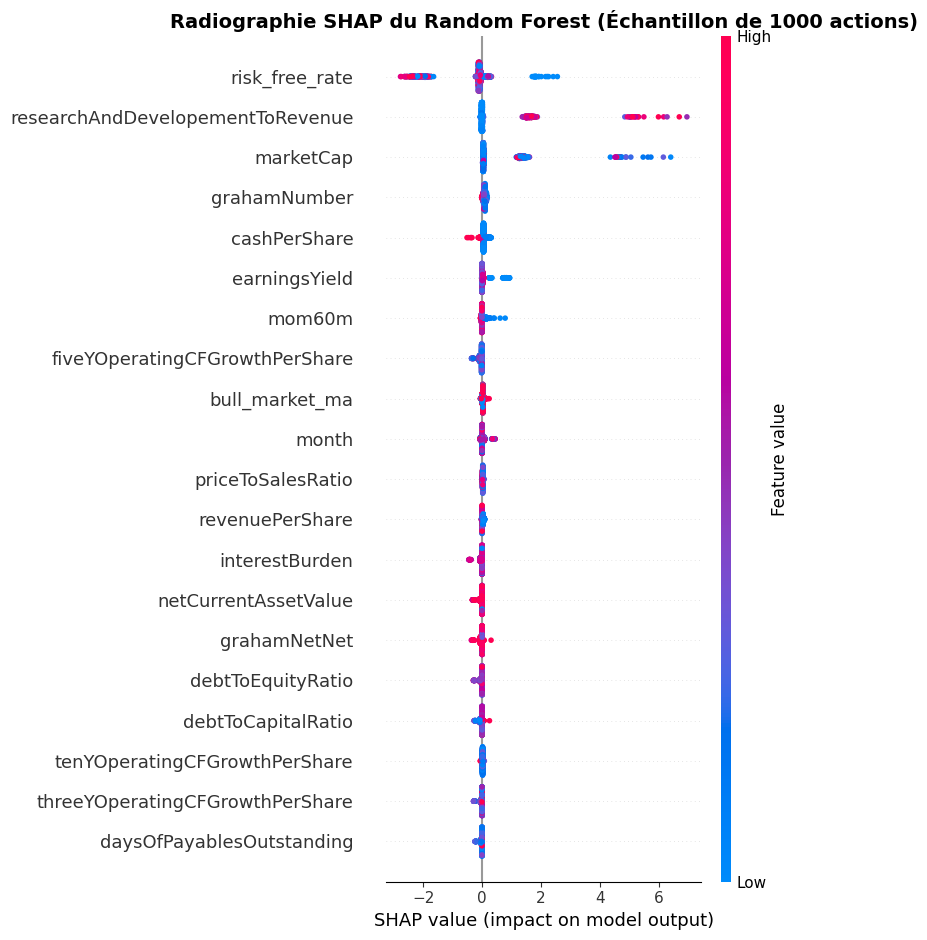

In [27]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚡ Calcul des SHAP sur un échantillon (Version Rapide)...")

# 1. LA MAGIE : On prend un échantillon de 1000 lignes au hasard
taille_echantillon = min(1000, X_test_scaled.shape[0])
indices_aleatoires = np.random.choice(X_test_scaled.shape[0], size=taille_echantillon, replace=False)
X_test_sample = X_test_scaled[indices_aleatoires]

# 2. On recrée l'explainer
explainer_rf = shap.TreeExplainer(rf_model)

# 3. On calcule UNIQUEMENT sur l'échantillon (Ça va prendre 5 secondes au lieu de 20 minutes !)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# 4. Formatage de la sortie (identique à avant)
if isinstance(shap_values_rf, list):
    shap_vals_rf_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    shap_vals_rf_to_plot = shap_values_rf[:, :, 1]
else:
    shap_vals_rf_to_plot = shap_values_rf

# 5. Affichage
plt.figure(figsize=(10, 8))
plt.title("Radiographie SHAP du Random Forest (Échantillon de 1000 actions)", fontsize=14, fontweight='bold')
# Attention : on donne bien X_test_sample au graphique pour que les couleurs correspondent !
shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features)

⚖️ Extraction des Coefficients du modèle Ridge...


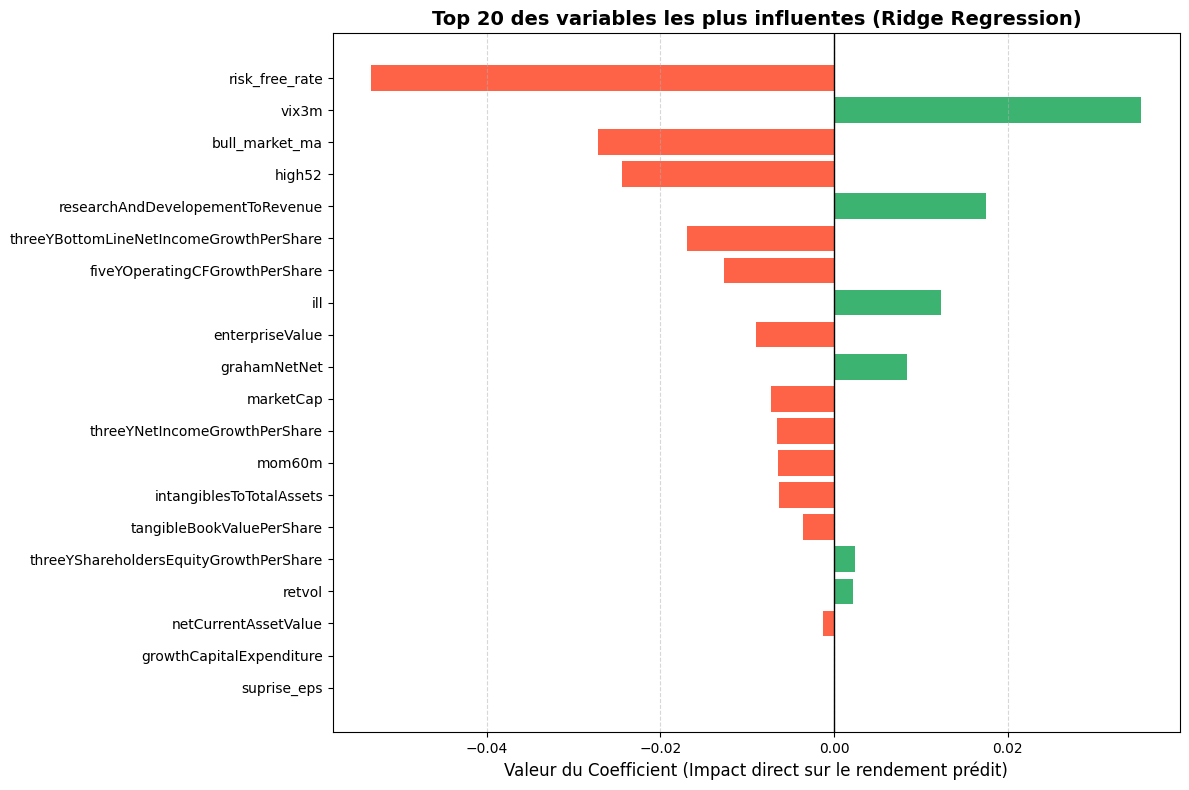


🗑️ Top 5 des variables ignorées par Ridge (Coefficients proches de 0) :
                        Feature  Coefficient
capitalExpenditureCoverageRatio         -0.0
       growthCapitalExpenditure          0.0
              receivablesGrowth         -0.0
                          mom1m          0.0
 operatingCashFlowCoverageRatio         -0.0


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("⚖️ Extraction des Coefficients du modèle Ridge...")

# 1. On récupère les coefficients directement dans le modèle
coefficients = lasso_model.coef_

# Si la sortie est un tableau 2D (ça arrive parfois avec scikit-learn), on l'aplatit
if coefficients.ndim > 1:
    coefficients = coefficients.flatten()

# 2. Création d'un DataFrame propre
ridge_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Importance': np.abs(coefficients) # Valeur absolue pour trouver les plus forts
})

# 3. On trie par la force de l'impact (la valeur absolue) et on prend le Top 20
top_ridge = ridge_importance.sort_values(by='Abs_Importance', ascending=False).head(20)

# 4. Affichage graphique "Façon Quant"
plt.figure(figsize=(12, 8))

# On inverse l'ordre avec [::-1] pour avoir le plus important en haut
features_plot = top_ridge['Feature'][::-1]
coefs_plot = top_ridge['Coefficient'][::-1]

# Code couleur : Vert si le coefficient est positif, Rouge s'il est négatif
couleurs = ['mediumseagreen' if x > 0 else 'tomato' for x in coefs_plot]

plt.barh(features_plot, coefs_plot, color=couleurs)

plt.title('Top 20 des variables les plus influentes (Ridge Regression)', fontsize=14, fontweight='bold')
plt.xlabel("Valeur du Coefficient (Impact direct sur le rendement prédit)", fontsize=12)
plt.axvline(x=0, color='black', linewidth=1) # La ligne zéro
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Affichage des pires variables (celles que Ridge a "écrasées" vers 0)
variables_ignorees = ridge_importance.sort_values(by='Abs_Importance', ascending=True).head(5)
print("\n🗑️ Top 5 des variables ignorées par Ridge (Coefficients proches de 0) :")
print(variables_ignorees[['Feature', 'Coefficient']].to_string(index=False))

In [29]:
# 1. On trie le tableau d'abord par date (chronologique), 
# puis par prédiction décroissante (du meilleur au pire score LightGBM)
top_10_per_date = final_test_df.sort_values(by=['date', 'lightgbm_pred'], ascending=[True, False])

# 2. On groupe par date et on ne garde que les 10 premières lignes de chaque groupe
top_10_per_date = top_10_per_date.groupby('date').head(5)

# 3. On affiche un aperçu épuré (Date, Action, Score IA, et le vrai résultat pour comparer)
colonnes_a_afficher = ['date', 'symbol', 'lightgbm_pred', 'target_y']
print(top_10_per_date[colonnes_a_afficher].tail(20)) # Affiche les 3 premières dates (3 x 10)

             date symbol  lightgbm_pred  target_y
351574 2025-12-05   MTCH       1.712433 -0.048841
99682  2025-12-05   CHTR       1.528830  0.008882
323005 2025-12-05   MCHP       1.357199  0.002323
259037 2025-12-05   INTC       1.331132  0.243923
232058 2025-12-05    HAS       1.270267  0.117575
351575 2025-12-12   MTCH       1.773824 -0.048841
99683  2025-12-12   CHTR       1.549166  0.008882
259038 2025-12-12   INTC       1.384908  0.243923
323006 2025-12-12   MCHP       1.383889  0.002323
232059 2025-12-12    HAS       1.259601  0.117575
351576 2025-12-19   MTCH       1.732240 -0.048841
99684  2025-12-19   CHTR       1.502198  0.008882
323007 2025-12-19   MCHP       1.340030  0.002323
259039 2025-12-19   INTC       1.335620  0.243923
232060 2025-12-19    HAS       1.227452  0.117575
351577 2025-12-26   MTCH       1.722579 -0.048841
99685  2025-12-26   CHTR       1.525962  0.008882
259040 2025-12-26   INTC       1.380643  0.243923
323008 2025-12-26   MCHP       1.358546  0.002323


In [30]:
final_test_df.sort_values(by='lightgbm_pred', ascending=True).head(50)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,week,target_y,dnn_pred,rf_pred,ols_pred,lasso_pred,ridge_pred,xgboost_pred,lightgbm_pred,catboost_pred
451140,SPG,2020-06-12,54.54,10647500,0.013061,0.000006,0.897030,0.841584,-0.259406,0.916832,...,4,0.957141,366.117249,0.592990,0.001732,0.245786,0.001883,0.757316,-0.771534,0.121394
451141,SPG,2020-06-19,48.18,13314847,-0.005649,0.000006,0.679208,-0.544554,-0.207921,0.782178,...,4,0.957141,331.761536,0.588629,-0.039022,0.195863,-0.038871,0.759937,-0.768358,0.130402
422138,RCL,2020-03-13,31.60,27483000,0.092871,0.000011,0.944334,-0.276342,-0.272366,0.964215,...,4,0.029585,778.269409,0.370229,0.013686,0.114566,0.013718,0.199187,-0.723197,0.130402
451133,SPG,2020-04-24,36.96,10104323,0.013918,0.000005,-0.515873,-0.738095,-0.424603,-0.948413,...,4,0.957141,228.762451,0.592554,0.219244,0.437140,0.219394,0.731841,-0.719126,0.121394
451135,SPG,2020-05-08,41.65,8342779,0.016872,0.000005,0.757937,-0.523810,-0.119048,0.837302,...,4,0.957141,228.763885,0.599089,0.229634,0.451779,0.229784,0.706242,-0.715897,0.121394
7761,ADBE,2022-09-16,299.50,14948057,-0.007182,0.000127,0.996094,-0.394531,-0.859375,0.925781,...,4,0.772799,10805.409180,0.514286,-4.251793,-3.707462,-4.252227,0.283444,-0.714420,0.121394
451136,SPG,2020-05-15,36.84,7579200,0.003926,0.000005,0.341270,-0.706349,-0.420635,-0.186508,...,4,0.957141,228.754242,0.592554,0.220877,0.444582,0.221027,0.716599,-0.707029,0.121394
7758,ADBE,2022-08-26,381.02,3600146,-0.033688,0.000115,0.253906,-0.988281,-0.867188,0.265625,...,4,0.772799,9740.853516,0.518914,-3.767109,-3.320412,-3.767621,0.225753,-0.682968,0.121394
7753,ADBE,2022-07-22,401.90,2413224,-0.009332,0.000099,0.479452,0.088063,-0.733855,0.600783,...,4,0.772799,8367.286133,0.373145,-3.106543,-2.784390,-3.107051,0.226832,-0.680560,0.121394
7751,ADBE,2022-07-08,389.44,1611201,-0.000830,0.000079,-0.240705,0.232877,-0.761252,-0.052838,...,4,0.772799,6615.965820,0.442566,-2.355340,-2.147813,-2.355844,0.243597,-0.665574,0.121394


In [31]:
final_test_df.sort_values(by=['date', 'lightgbm_pred'], ascending=[False, False]).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,week,target_y,dnn_pred,rf_pred,ols_pred,lasso_pred,ridge_pred,xgboost_pred,lightgbm_pred,catboost_pred
351577,MTCH,2025-12-26,32.35,1692441,-0.000301,0.000144,-0.200000,-0.811538,0.769231,-0.092308,...,4,-0.048841,12316.353516,1.251790,-5.068838,-4.350939,-5.068822,1.666368,1.722579,0.121394
99685,CHTR,2025-12-26,207.16,791100,-0.000301,0.000144,0.369231,0.480769,0.411538,0.219231,...,4,0.008882,12316.333984,1.358274,-4.810613,-4.385772,-4.810487,4.413297,1.525962,0.130402
259040,INTC,2025-12-26,36.20,28779400,-0.000301,0.000144,-0.326923,-0.969231,-0.942308,-0.803846,...,4,0.243923,12316.331055,1.045164,-5.119892,-4.414520,-5.120172,0.089714,1.380643,0.126348
323008,MCHP,2025-12-26,64.56,3853600,-0.000301,0.000144,0.807692,0.753846,-0.057692,0.819231,...,4,0.002323,12316.330078,0.727147,-5.121021,-4.365408,-5.121049,0.776472,1.358546,0.121394
232061,HAS,2025-12-26,81.99,660100,-0.000301,0.000144,-0.123077,0.046154,0.784615,-0.911538,...,4,0.117575,12316.340820,0.518419,-5.185360,-4.413876,-5.185331,1.114114,1.241615,0.121394
86444,CAH,2025-12-26,207.77,591039,-0.000301,0.000144,-0.519231,0.011538,-0.223077,0.211538,...,4,0.019733,12316.333984,0.173892,-5.164123,-4.474717,-5.164226,0.436360,1.106399,0.121394
188740,EXPE,2025-12-26,286.94,534040,-0.000301,0.000144,-0.700000,-0.842308,-0.273077,-0.569231,...,4,-0.163449,12316.339844,0.724110,-5.077596,-4.453505,-5.077657,0.564399,1.100420,0.121394
356168,NCLH,2025-12-26,22.81,8498900,-0.000301,0.000144,0.992308,0.996154,0.753846,0.984615,...,4,-0.131960,12316.369141,0.403417,-4.245095,-4.371756,-4.245051,0.770603,1.052317,0.117847
1056,AAL,2025-12-26,15.44,37777143,-0.000301,0.000144,0.984615,0.926923,-0.203846,0.934615,...,4,-0.300518,12316.338867,1.320461,-5.018954,-4.398656,-5.018859,2.481121,1.020364,0.121394
514635,WB,2025-12-26,10.14,239100,-0.000301,0.000144,-0.223077,-0.634615,0.992308,-0.869231,...,4,-0.147929,12316.312500,1.150767,-5.059742,-4.341761,-5.059736,1.419704,1.008411,0.121735


26/03/19 19:48:05 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE